# 05. Modeling
## Digital Burnout Prediction - International Dataset

- Xây dựng và so sánh nhiều mô hình Machine Learning để dự đoán `burnout_risk`.
- Sử dụng các chỉ báo đã được làm sạch và/hoặc validated từ notebook trước.
- Đánh giá mô hình bằng các chỉ số classification.
- Lựa chọn mô hình tốt nhất cho bài toán dự đoán Digital Burnout.

## Import thư viện

In [1]:
# Import libraries

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False

try:
    from catboost import CatBoostClassifier
    catboost_available = True
except ImportError:
    catboost_available = False

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

## 1. Load Dataset

Dataset đầu vào là:

`digital_burnout_cleaned.csv`

Notebook này không dùng `digital_burnout_processed.csv` vì encoding và scaling phải được thực hiện bên trong Modeling Pipeline để tránh data leakage.

In [2]:
# Load cleaned dataset

data_path = "../../data/processed/international_dataset/digital_burnout_cleaned.csv"

df = pd.read_csv(data_path)

print("Cleaned dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Cleaned dataset loaded successfully.
Dataset shape: (5000000, 34)


## 2. Load Validated Indicators

Nếu đã có `validated_indicators.csv`, notebook sẽ ưu tiên sử dụng các chỉ báo được khuyến nghị từ Feature Validation.

Nếu chưa có file này, notebook sẽ sử dụng danh sách research variables ban đầu.

Điều này giúp notebook chạy được trong cả hai trường hợp:

- Đã hoàn thành Feature Validation và có file validated indicators.
- Chỉ mới có cleaned dataset.

In [3]:
# Define fallback research features

fallback_features = [
    # Burnout Symptoms
    "emotional_exhaustion",
    "stress_level",
    "mental_fatigue",
    
    # Digital Exposure
    "daily_screen_time",
    "social_media_hours",
    "doomscrolling_duration",
    "late_night_device_usage",
    "notification_count",
    "smartphone_unlocks",
    "app_switch_frequency",
    
    # Cognitive Performance
    "concentration_score",
    "distraction_frequency",
    "focus_sessions",
    "deep_work_hours",
    "task_completion_rate",
    "motivation_level",
    
    # Sleep & Recovery
    "sleep_hours",
    "sleep_quality",
    
    # Context Variables
    "work_mode",
    "device_usage_type"
]

validated_path = "../../data/processed/international_dataset/validated_indicators.csv"

if os.path.exists(validated_path):
    validated_indicators = pd.read_csv(validated_path)
    
    print("Validated indicators loaded successfully.")
    display(validated_indicators.head())
    
    if "Recommendation" in validated_indicators.columns:
        selected_features = validated_indicators[
            validated_indicators["Recommendation"].isin([
                "Retain as core indicator",
                "Retain as candidate indicator",
                "Review with theoretical support"
            ])
        ]["Indicator"].tolist()
    else:
        selected_features = validated_indicators["Indicator"].tolist()
else:
    print("validated_indicators.csv not found.")
    print("Using fallback research features.")
    selected_features = fallback_features

selected_features = [
    col for col in selected_features 
    if col in df.columns
]

print("Selected features:")
print(selected_features)

print(f"\nNumber of selected features: {len(selected_features)}")

Validated indicators loaded successfully.


,Indicator,Correlation,p-value,Evidence Strength,Recommendation
0,deep_work_hours,0.556077,0.0,Strong,Retain as core indicator
1,emotional_exhaustion,0.509398,0.0,Strong,Retain as core indicator
2,stress_level,0.376978,0.0,Moderate,Retain as candidate indicator
3,task_completion_rate,0.353570,0.0,Moderate,Retain as candidate indicator
4,concentration_score,0.345042,0.0,Moderate,Retain as candidate indicator


Selected features:
['deep_work_hours', 'emotional_exhaustion', 'stress_level', 'task_completion_rate', 'concentration_score', 'focus_sessions', 'motivation_level', 'daily_screen_time', 'doomscrolling_duration', 'late_night_device_usage', 'distraction_frequency', 'social_media_hours', 'sleep_hours']

Number of selected features: 13


## 3. Feature Matrix and Target Definition

Target chính của notebook là:

`burnout_risk`

Vì các metric yêu cầu như Accuracy, Precision, Recall, F1-score và ROC-AUC là classification metrics, biến `burnout_risk` cần được chuyển thành nhãn phân loại.

Cách xử lý:

- Nếu `burnout_risk` đã là biến phân loại: sử dụng trực tiếp.
- Nếu `burnout_risk` là biến liên tục: chuyển thành binary target dựa trên median.

Quy ước:

- 0 = Low / Lower Burnout Risk
- 1 = High / Higher Burnout Risk

In [4]:
# Define target

target_column = "burnout_risk"

if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found in dataset.")

X = df[selected_features].copy()
y_raw = df[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y_raw.shape)

Feature matrix shape: (5000000, 13)
Target shape: (5000000,)


In [5]:
# Convert target to classification label

if pd.api.types.is_numeric_dtype(y_raw):
    threshold = y_raw.median()
    y = (y_raw >= threshold).astype(int)
    print(f"Numeric target detected. Converted to binary classification using median threshold: {threshold:.4f}")
else:
    y = y_raw.astype("category").cat.codes
    print("Categorical target detected. Converted to numeric class labels.")

print("\nTarget distribution:")
display(pd.Series(y).value_counts().reset_index().rename(
    columns={
        "index": "class",
        "count": "count"
    }
))

Numeric target detected. Converted to binary classification using median threshold: 48.0000

Target distribution:


,burnout_risk,count
0,1,2583844
1,0,2416156


## 4. Train/Test Split

Dữ liệu được chia thành:

- Training set: 80%
- Test set: 20%

Sử dụng stratified split để giữ tỷ lệ lớp của target giữa train và test.

In [6]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain target distribution:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTest target distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

X_train shape: (4000000, 13)
X_test shape: (1000000, 13)

Train target distribution:
burnout_risk
1    0.516769
0    0.483231
Name: proportion, dtype: float64

Test target distribution:
burnout_risk
1    0.516769
0    0.483231
Name: proportion, dtype: float64


## 5. Preprocessing Pipeline

Preprocessing được đặt bên trong pipeline để tránh data leakage.

Chiến lược:

- Numeric features:
  - Median imputation
  - StandardScaler

- Categorical features:
  - Most frequent imputation
  - OneHotEncoder

Riêng CatBoost có khả năng xử lý categorical tốt, nhưng để notebook nhất quán và dễ so sánh, phiên bản này vẫn dùng pipeline chuẩn của scikit-learn.

In [7]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['deep_work_hours', 'emotional_exhaustion', 'stress_level', 'task_completion_rate', 'concentration_score', 'focus_sessions', 'motivation_level', 'daily_screen_time', 'doomscrolling_duration', 'late_night_device_usage', 'distraction_frequency', 'social_media_hours', 'sleep_hours']

Categorical features:
[]


In [8]:
# Define preprocessing pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

## 6. Model Selection

Dựa trên Literature Review và bảng tổng hợp mô hình, notebook này chọn 5 mô hình:

### Baseline Model

1. Logistic Regression

### Traditional ML Models

2. Decision Tree  
3. Random Forest  

### Advanced ML Models

4. XGBoost  
5. CatBoost  

Lý do chọn:

- Logistic Regression: baseline tuyến tính, dễ so sánh.
- Decision Tree: baseline cây quyết định dễ hiểu.
- Random Forest: baseline mạnh cho dữ liệu tabular.
- XGBoost: mô hình boosting mạnh, thường hiệu quả với quan hệ phi tuyến.
- CatBoost: phù hợp với dữ liệu có categorical variables.

In [12]:
# Define models with GPU support for XGBoost and CatBoost

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )
}

if xgboost_available:
    models["XGBoost GPU"] = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        device="cuda",
        random_state=RANDOM_STATE
    )
else:
    print("XGBoost is not installed. Skipping XGBoost.")

if catboost_available:
    models["CatBoost GPU"] = CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        task_type="GPU",
        devices="0",
        random_seed=RANDOM_STATE,
        verbose=False
    )
else:
    print("CatBoost is not installed. Skipping CatBoost.")

print("Models included:")
print(list(models.keys()))

Models included:
['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost GPU', 'CatBoost GPU']


## 7. Cross-Validation

Trước khi đánh giá trên test set, notebook sử dụng Stratified 5-Fold Cross Validation trên training set.

Mục tiêu:

- Kiểm tra tính ổn định của mô hình.
- Giảm phụ thuộc vào một lần chia train/test duy nhất.
- Tăng độ tin cậy cho phần so sánh mô hình.

In [13]:
# Cross-validation setup

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [14]:
# Run cross-validation

cv_results = []

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    cv_results.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df.sort_values(by="CV ROC-AUC", ascending=False))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
4,CatBoost GPU,0.776700,0.781666,0.787994,0.784817,0.862066
3,XGBoost GPU,0.776474,0.782086,0.786638,0.784355,0.861874
0,Logistic Regression,0.776103,0.788044,0.775252,0.781596,0.861626
2,Random Forest,0.768791,0.782983,0.764474,0.773618,0.853165
1,Decision Tree,0.735221,0.754082,0.723955,0.738581,0.810695


## 8. Model Training and Test Evaluation

Sau Cross-Validation, các mô hình được huấn luyện trên training set và đánh giá trên test set.

Các metric sử dụng:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Trong bài toán Digital Burnout, Recall đặc biệt quan trọng vì mục tiêu là giảm nguy cơ bỏ sót sinh viên có nguy cơ burnout cao.

In [15]:
# Train and evaluate models

trained_models = {}
evaluation_results = []
predictions = {}
prediction_probabilities = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    trained_models[model_name] = pipeline
    predictions[model_name] = y_pred
    prediction_probabilities[model_name] = y_proba
    
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

model_comparison = pd.DataFrame(evaluation_results)

display(model_comparison.sort_values(by="ROC-AUC", ascending=False))

Default metric period is 5 because AUC is/are not implemented for GPU


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,CatBoost GPU,0.775785,0.780466,0.787687,0.784060,0.861769
3,XGBoost GPU,0.775663,0.781121,0.786183,0.783644,0.861607
0,Logistic Regression,0.775056,0.786756,0.774683,0.780673,0.861356
2,Random Forest,0.767866,0.782434,0.762944,0.772566,0.852616
1,Decision Tree,0.735418,0.760479,0.712378,0.735643,0.810442


## 9. Classification Reports

Phần này hiển thị báo cáo classification chi tiết cho từng mô hình.

Mục tiêu:

- Xem hiệu quả dự đoán từng lớp.
- Đánh giá Precision, Recall và F1-score ở cấp độ class.

In [16]:
# Classification reports

for model_name, y_pred in predictions.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.76      0.78      0.77    483231
           1       0.79      0.77      0.78    516769

    accuracy                           0.78   1000000
   macro avg       0.77      0.78      0.77   1000000
weighted avg       0.78      0.78      0.78   1000000

Decision Tree
              precision    recall  f1-score   support

           0       0.71      0.76      0.74    483231
           1       0.76      0.71      0.74    516769

    accuracy                           0.74   1000000
   macro avg       0.74      0.74      0.74   1000000
weighted avg       0.74      0.74      0.74   1000000

Random Forest
              precision    recall  f1-score   support

           0       0.75      0.77      0.76    483231
           1       0.78      0.76      0.77    516769

    accuracy                           0.77   1000000
   macro avg       0.77      0.77      0.77   1000000
weighted avg       0.77   

## 10. Confusion Matrix

Confusion Matrix giúp quan sát:

- True Negative
- False Positive
- False Negative
- True Positive

Trong bài toán Digital Burnout, False Negative là trường hợp đáng chú ý vì mô hình bỏ sót sinh viên có nguy cơ burnout cao.

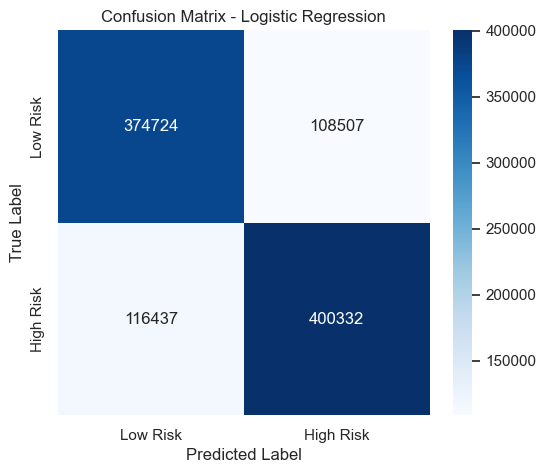

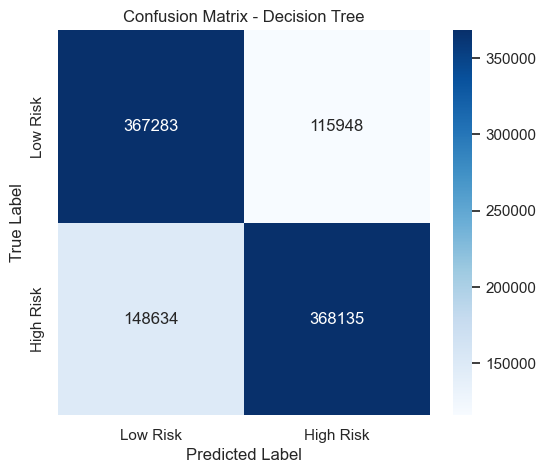

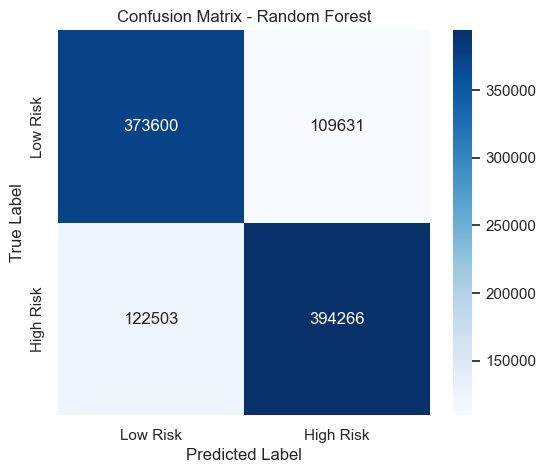

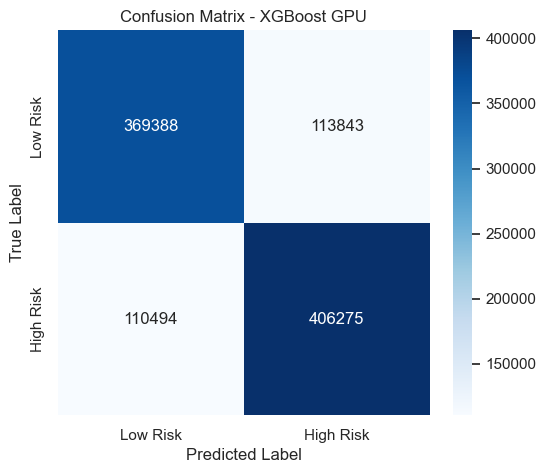

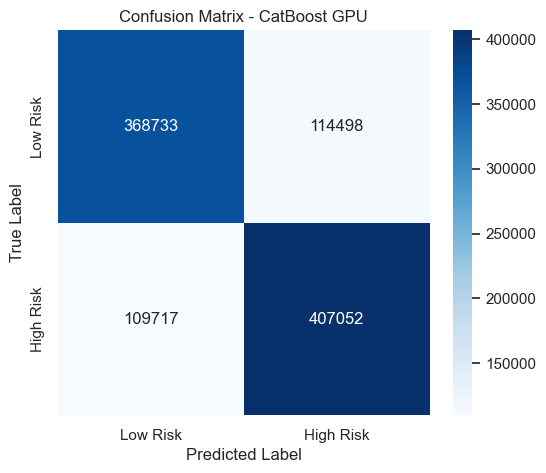

In [17]:
# Plot confusion matrices

for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low Risk", "High Risk"],
        yticklabels=["Low Risk", "High Risk"]
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

## 11. ROC Curves

ROC Curve giúp so sánh khả năng phân biệt giữa hai lớp của các mô hình.

ROC-AUC càng cao cho thấy mô hình càng có khả năng phân biệt tốt giữa nhóm burnout risk thấp và cao.

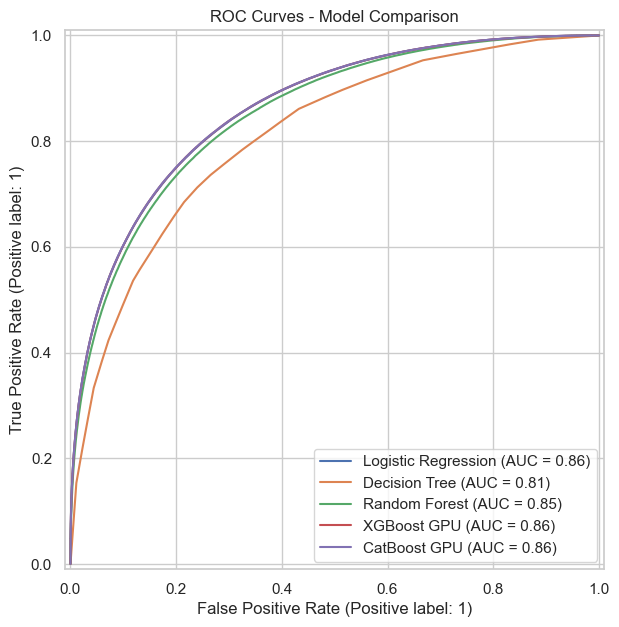

In [18]:
# Plot ROC curves

plt.figure(figsize=(10, 7))

for model_name, pipeline in trained_models.items():
    y_proba = prediction_probabilities[model_name]
    
    if y_proba is not None:
        RocCurveDisplay.from_predictions(
            y_test,
            y_proba,
            name=model_name,
            ax=plt.gca()
        )

plt.title("ROC Curves - Model Comparison")
plt.show()

## 12. Model Comparison Table

Bảng cuối cùng của notebook:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |

Bảng này là cơ sở để lựa chọn mô hình tốt nhất.

In [19]:
# Final model comparison table

final_model_comparison = model_comparison[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
].sort_values(by="ROC-AUC", ascending=False)

display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,CatBoost GPU,0.775785,0.780466,0.787687,0.784060,0.861769
3,XGBoost GPU,0.775663,0.781121,0.786183,0.783644,0.861607
0,Logistic Regression,0.775056,0.786756,0.774683,0.780673,0.861356
2,Random Forest,0.767866,0.782434,0.762944,0.772566,0.852616
1,Decision Tree,0.735418,0.760479,0.712378,0.735643,0.810442


## 13. Best Model Selection

Tiêu chí lựa chọn mô hình tốt nhất:

1. Ưu tiên ROC-AUC để đánh giá khả năng phân biệt tổng thể.
2. Xem xét Recall vì bài toán Digital Burnout cần hạn chế bỏ sót sinh viên nguy cơ cao.
3. Xem xét F1-score để cân bằng Precision và Recall.

Trong trường hợp hai mô hình có ROC-AUC gần nhau, mô hình có Recall cao hơn sẽ được ưu tiên.

In [20]:
# Select best model

model_selection_table = final_model_comparison.copy()

model_selection_table["selection_score"] = (
    0.40 * model_selection_table["ROC-AUC"] +
    0.35 * model_selection_table["Recall"] +
    0.25 * model_selection_table["F1"]
)

model_selection_table = model_selection_table.sort_values(
    by="selection_score",
    ascending=False
)

display(model_selection_table)

best_model_name = model_selection_table.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best selected model: {best_model_name}")

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,selection_score
4,CatBoost GPU,0.775785,0.780466,0.787687,0.784060,0.861769,0.816413
3,XGBoost GPU,0.775663,0.781121,0.786183,0.783644,0.861607,0.815718
0,Logistic Regression,0.775056,0.786756,0.774683,0.780673,0.861356,0.810850
2,Random Forest,0.767866,0.782434,0.762944,0.772566,0.852616,0.801219
1,Decision Tree,0.735418,0.760479,0.712378,0.735643,0.810442,0.757420


Best selected model: CatBoost GPU


## 14. Save Best Model

Theo yêu cầu hiện tại, notebook này KHÔNG xuất file model.

Khi cần triển khai hoặc dùng cho notebook sau, có thể lưu model bằng `joblib`.

Cell bên dưới chỉ in hướng dẫn, không thực hiện lưu file.

In [ ]:
# No model export in this notebook

print("Best model is stored in memory as `best_model`.")
print("Best model name:", best_model_name)
print("No model file is exported in this notebook.")

In [ ]:
# Optional code for future use only
# Do not run this cell if you do not want to export files.

# import joblib
# model_output_path = "../../models/international_dataset/best_burnout_model.pkl"
# joblib.dump(best_model, model_output_path)
# print(f"Best model saved to: {model_output_path}")

In [21]:
# Notebook output summary

notebook_output_summary = pd.DataFrame({
    "output": [
        "cv_results_df",
        "model_comparison",
        "classification_report",
        "confusion_matrix",
        "roc_curves",
        "final_model_comparison",
        "best_model",
        "research_findings"
    ],
    "purpose": [
        "Evaluate model stability using cross-validation",
        "Evaluate model performance on test set",
        "Inspect class-level model performance",
        "Analyze prediction errors",
        "Compare classification ability",
        "Rank models by evaluation metrics",
        "Store selected model in memory",
        "Support research discussion"
    ],
    "next_stage": [
        "Model Evaluation",
        "Best Model Selection",
        "Research Discussion",
        "Error Analysis",
        "Best Model Selection",
        "Research Reporting",
        "Interpretability Notebook",
        "Research Conclusions"
    ]
})

display(notebook_output_summary)

,output,purpose,next_stage
0,cv_results_df,Evaluate model stability using cross-validation,Model Evaluation
1,model_comparison,Evaluate model performance on test set,Best Model Selection
2,classification_report,Inspect class-level model performance,Research Discussion
3,confusion_matrix,Analyze prediction errors,Error Analysis
4,roc_curves,Compare classification ability,Best Model Selection
5,final_model_comparison,Rank models by evaluation metrics,Research Reporting
6,best_model,Store selected model in memory,Interpretability Notebook
7,research_findings,Support research discussion,Research Conclusions
